## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

TensorFlow version: 2.21.0
OpenCV version: 4.13.0


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 




## Punto 1

In [22]:
BASE_PATH = 'data'
TRAIN_DIRS = ['github_train_0', 'github_train_1', 'github_train_2', 'github_train_3']
TEST_DIR = 'github_test'
IMG_SIZE = (32, 32)
CLASS_NAMES = ['cat', 'dog']

In [23]:
def load_images_from_dirs(directories, base_path, size=(32, 32)):
    X, y, filenames = [], [], []
    if isinstance(directories, str):
        directories = [directories]
    for d in directories:
        path = os.path.join(base_path, d)
        for fname in sorted(os.listdir(path)):
            if not fname.lower().endswith('.jpg'):
                continue
            # 0 = gato, 1 = perro
            label = 0 if fname.startswith('cat') else 1
            img = cv2.imread(os.path.join(path, fname))
            if img is not None:
                img = cv2.resize(img, size)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                X.append(img)
                y.append(label)
                filenames.append(fname)
    return np.array(X), np.array(y), filenames

In [25]:
# Imágenes para train (4 directorios = 4000 imágenes)
X_train_raw, y_train, train_filenames = load_images_from_dirs(TRAIN_DIRS, BASE_PATH, IMG_SIZE)

# Imágenes para test
X_test_raw, y_test, test_filenames = load_images_from_dirs(TEST_DIR, BASE_PATH, IMG_SIZE)

print(f"\nTrain:")
print(f"  X_train shape: {X_train_raw.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  Gatos: {(y_train==0).sum()} | Perros: {(y_train==1).sum()}")

print(f"\nTest:")
print(f"  X_test shape : {X_test_raw.shape}")
print(f"  y_test shape : {y_test.shape}")
print(f"  Gatos: {(y_test==0).sum()} | Perros): {(y_test==1).sum()}")


Train:
  X_train shape: (4000, 32, 32, 3)
  y_train shape: (4000,)
  Gatos: 2000 | Perros: 2000

Test:
  X_test shape : (1000, 32, 32, 3)
  y_test shape : (1000,)
  Gatos: 500 | Perros): 500


In [26]:
# Normalizamos a [0,1]
X_train = X_train_raw / 255.0
X_test  = X_test_raw  / 255.0

print(f"Antes de normalizar: [{X_train_raw.min()}, {X_train_raw.max()}]")
print(f"Después de normalizar: [{X_train.min():.1f}, {X_train.max():.1f}]")

Antes de normalizar: [0, 255]
Después de normalizar: [0.0, 1.0]



## Punto 2

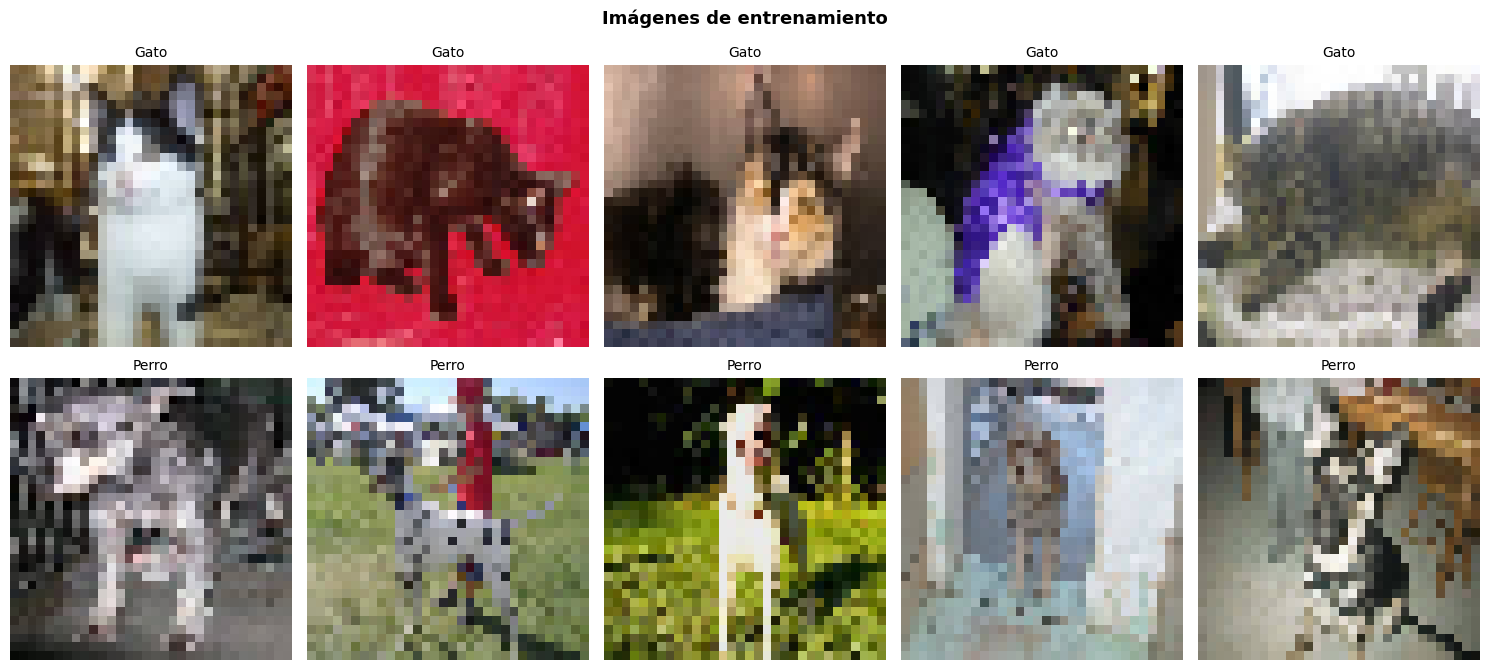

In [27]:
def plot_sample_images(X, y, n_per_class=5, title="Muestra de imágenes"):
    fig, axes = plt.subplots(2, n_per_class, figsize=(3*n_per_class, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    
    indices_cats = np.where(y == 0)[0][:n_per_class]
    indices_dogs = np.where(y == 1)[0][:n_per_class]
    
    for i, idx in enumerate(indices_cats):
        axes[0, i].imshow(X[idx])
        axes[0, i].set_title("Gato", fontsize=10)
        axes[0, i].axis('off')
    
    for i, idx in enumerate(indices_dogs):
        axes[1, i].imshow(X[idx])
        axes[1, i].set_title("Perro", fontsize=10)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()

plot_sample_images(X_train, y_train,
                   title="Imágenes de entrenamiento")

### Distribución de clases

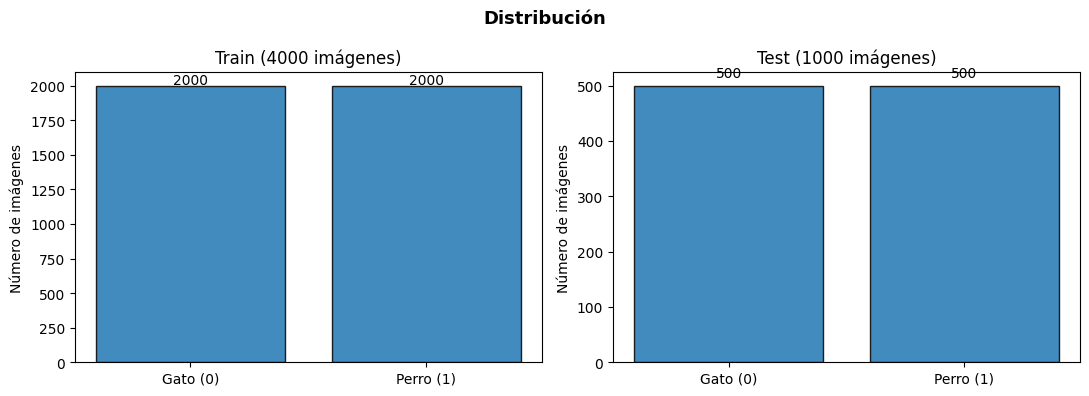

Conclusión: Dataset equilibrado (50% gatos, 50% perros)


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Distribución', fontsize=13, fontweight='bold')

for ax, (split_name, y_split) in zip(axes, [("Train (4000 imágenes)", y_train),
                                             ("Test (1000 imágenes)", y_test)]):
    counts = pd.Series(y_split).value_counts().sort_index()
    bars = ax.bar(['Gato (0)', 'Perro (1)'], counts.values,
                  edgecolor='black', alpha=0.85)
    ax.set_title(split_name)
    ax.set_ylabel('Número de imágenes')
    
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 15,
                str(v), ha='center')

plt.tight_layout()
plt.show()

print("Conclusión: Dataset equilibrado (50% gatos, 50% perros)")

### Construcción del modelo CNN

Diseño de la arquitectura:

- **Bloque 1**: Conv2D (32 filtros, 3×3) → MaxPool (2×2) → Dropout(0.25)
- **Bloque 2**: Conv2D (64 filtros, 3×3) → MaxPool (2×2) → Dropout(0.25)  
- **Cabeza densa**: Flatten → Dense(256, relu) → Dropout(0.5) → Dense(1, sigmoid)

Notas de diseño:
- Entrada: 32×32×3 (imágenes RGB)
- Salida: 1 neurona con sigmoid → clasificación binaria (gato=0, perro=1)
- Dropout como regularización para evitar overfitting
- Loss: binary_crossentropy (problema binario)
- Optimizador: Adam con lr=0.001

In [40]:
INPUT_SHAPE = (32, 32, 3)  # ancho x alto x canales RGB

model = Sequential([
    # ===================================================
    # Bloque 1: Convolucional + Pooling
    # ===================================================
    # Entrada 32x32x3 → Salida conv: 32x32x32
    Conv2D(filters=32, kernel_size=(3, 3), padding='Same',
           activation='relu', input_shape=INPUT_SHAPE),
    # Pooling: 32x32x32 → 16x16x32
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(rate=0.25),  # Poda del 25% para regularizar

    # ===================================================
    # Bloque 2: Convolucional + Pooling
    # ===================================================
    # 16x16x32 → 16x16x64
    Conv2D(filters=64, kernel_size=(3, 3), padding='Same', activation='relu'),
    # 16x16x64 → 8x8x64
    MaxPool2D(pool_size=(2, 2), strides=(2, 2)),
    Dropout(rate=0.25),

    # ===================================================
    # Cabeza densa (clasificación)
    # ===================================================
    Flatten(),  # 8×8×64 = 4096 features
    Dense(256, activation='relu'),
    Dropout(rate=0.5),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,068,481 (4.08 MB)

 Trainable params: 1,068,481 (4.08 MB)

 Non-trainable params: 0 (0.00 B)


## Punto 3

In [43]:
# Callback de EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

BATCH_SIZE = 64
EPOCHS = 50   # Máximo, porque no se donde cortará

print(f"Configuración de entrenamiento:")
print(f"  batch_size      : {BATCH_SIZE}")
print(f"  epochs máx      : {EPOCHS}")
print(f"  EarlyStopping   : patience=5 sobre val_loss\n")

history = model.fit(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Configuración de entrenamiento:
  batch_size      : 64
  epochs máx      : 50
  EarlyStopping   : patience=5 sobre val_loss

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7716 - loss: 0.4928 - val_accuracy: 0.4500 - val_loss: 0.8860
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7578 - loss: 0.4981 - val_accuracy: 0.6950 - val_loss: 0.5941
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7728 - loss: 0.4778 - val_accuracy: 0.6687 - val_loss: 0.6001
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7772 - loss: 0.4650 - val_accuracy: 0.6938 - val_loss: 0.5818
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7872 - loss: 0.4531 - val_accuracy: 0.7412 - val_loss: 0.5046
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7953 - loss: 0.4428 - val_accuracy: 0.7050 - val_loss: 0.5698
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8047 - loss: 0.4241 - val_accuracy: 0.5600 - val

In [45]:
# Historial completo de entrenamiento
history_df = pd.DataFrame(history.history)
print("Historial:")
history_df

Historial:


,accuracy,loss,val_accuracy,val_loss
0,0.771563,0.492764,0.45000,0.885960
1,0.757812,0.498065,0.69500,0.594139
2,0.772812,0.477836,0.66875,0.600095
3,0.777188,0.464991,0.69375,0.581828
4,0.787188,0.453099,0.74125,0.504614
5,0.795313,0.442812,0.70500,0.569848
6,0.804688,0.424133,0.56000,0.764708
7,0.814062,0.411534,0.58750,0.760027
8,0.813438,0.410323,0.67250,0.593938
9,0.828750,0.382381,0.57500,0.810255


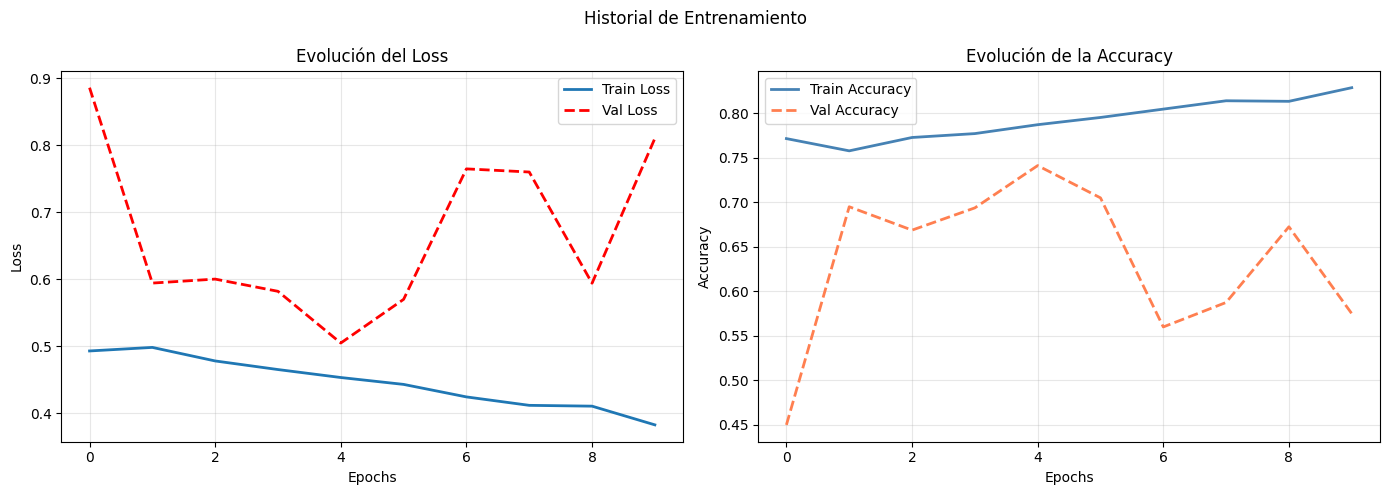


Epochs entrenados: 10
Mejor accuracy: 0.7412 (epoch 5)
Mejor loss:     0.5046 (epoch 5)


In [46]:
# Visualización del historial
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Historial de Entrenamiento')

# Loss
axes[0].plot(history_df['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history_df['val_loss'], label='Val Loss', color='red', linewidth=2, linestyle='--')
axes[0].set_title('Evolución del Loss')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history_df['accuracy'], label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history_df['val_accuracy'], label='Val Accuracy', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('Evolución de la Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEpochs entrenados: {len(history_df)}")
print(f"Mejor accuracy: {history_df['val_accuracy'].max():.4f} (epoch {history_df['val_accuracy'].idxmax()+1})")
print(f"Mejor loss:     {history_df['val_loss'].min():.4f} (epoch {history_df['val_loss'].idxmin()+1})")


## Ejercicio 4: Evaluación del modelo

In [47]:
# Evaluación sobre el conjunto de test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

  Test Loss     : 0.5222
  Test Accuracy : 0.7510 (75.10%)


In [48]:
# Predicciones sobre test
y_pred_proba = model.predict(X_test, verbose=0).flatten()

# Umbral 0.5: >= 0.5 -> perro (1), < 0.5 -> gato (0)
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"Como se distribuyen las predicciones: {(y_pred==0).sum()} gatos, {(y_pred==1).sum()} perros")

Como se distribuyen las predicciones: 489 gatos, 511 perros


In [49]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Gato (0)', 'Perro (1)']))

Reporte de Clasificación:
              precision    recall  f1-score   support

    Gato (0)       0.76      0.74      0.75       500
   Perro (1)       0.75      0.76      0.75       500

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75      0.75      1000



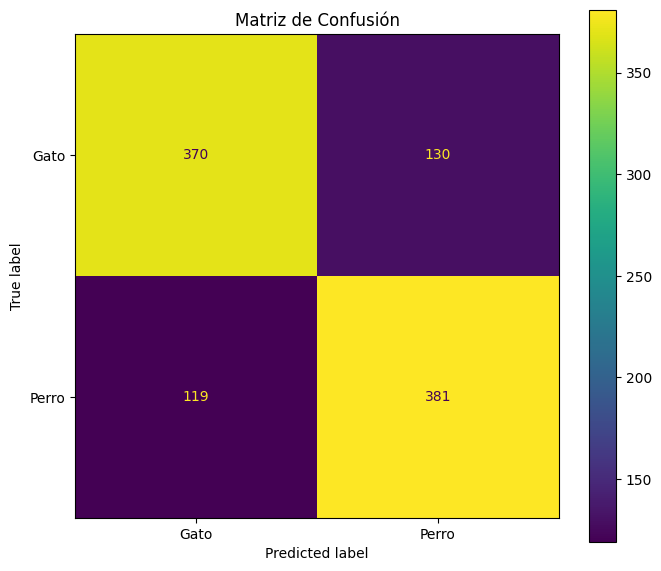


Gatos mal clasificados como perros: 130 / 500 (26.0%)
Perros mal clasificados como gatos: 119 / 500 (23.8%)


In [51]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Gato', 'Perro'],
    ax=ax
)
ax.set_title('Matriz de Confusión')
plt.tight_layout()
plt.show()

# Resumen de errores
gatos_mal = ((y_test == 0) & (y_pred == 1)).sum()
perros_mal = ((y_test == 1) & (y_pred == 0)).sum()
print(f"\nGatos mal clasificados como perros: {gatos_mal} / {(y_test==0).sum()} ({gatos_mal/(y_test==0).sum()*100:.1f}%)")
print(f"Perros mal clasificados como gatos: {perros_mal} / {(y_test==1).sum()} ({perros_mal/(y_test==1).sum()*100:.1f}%)")


## Ejercicio 5

- Gatos difíciles: clasificados como perro con la mayor probabilidad P(perro)
- Perros difíciles: clasificados como gato con la mayor probabilidad P(gato) = 1 - P(perro)

In [52]:
test_filenames_arr = np.array(test_filenames)

# ── Gatos mal clasificados como perros ──────────────────────────────
mask_gatos_mal = (y_test == 0) & (y_pred == 1)
indices_gatos_mal = np.where(mask_gatos_mal)[0]
# Ordenar por mayor Probabilidsad de perro: el que tenga mayor prob de ser perro es el más engañoso
gatos_mal_sorted = indices_gatos_mal[np.argsort(y_pred_proba[indices_gatos_mal])[::-1]]

# ── Perros mal clasificados como gatos ──────────────────────────────
mask_perros_mal = (y_test == 1) & (y_pred == 0)
indices_perros_mal = np.where(mask_perros_mal)[0]
# Ordenar por mayor Probabilidad de gato = menor Probabilidad de perro
perros_mal_sorted = indices_perros_mal[np.argsort(y_pred_proba[indices_perros_mal])]

# ── Calcular 10% de cada clase ──────────────────────────────────────
n_gatos_test = (y_test == 0).sum()
n_perros_test = (y_test == 1).sum()
n_sel_gatos  = max(1, int(np.ceil(n_gatos_test  * 0.10)))
n_sel_perros = max(1, int(np.ceil(n_perros_test * 0.10)))

print(f"Imágenes de gato en test: {n_gatos_test} → estois son el 10%: {n_sel_gatos}")
print(f"Imágenes de perro en test: {n_perros_test} → estos son el 10%: {n_sel_perros}")
print(f"\nGatos clasificados mal: {len(indices_gatos_mal)}")
print(f"Perros clasificados mal: {len(indices_perros_mal)}")

# Selección final
gatos_seleccionados  = gatos_mal_sorted[:n_sel_gatos]
perros_seleccionados = perros_mal_sorted[:n_sel_perros]

print(f"\n Gatos seleccionados para CAPTCHA: {len(gatos_seleccionados)}")
print(f" Perros seleccionados para CAPTCHA: {len(perros_seleccionados)}")

Imágenes de gato en test: 500 → estois son el 10%: 50
Imágenes de perro en test: 500 → estos son el 10%: 50

Gatos clasificados mal: 130
Perros clasificados mal: 119

 Gatos seleccionados para CAPTCHA: 50
 Perros seleccionados para CAPTCHA: 50


In [ ]:
print("Top 10 gatos más difíciles")
df_top_gatos = pd.DataFrame({
    'Archivo': test_filenames_arr[gatos_seleccionados[:10]],
    'Clase Real': 'gato',
    'Clase Predicha': 'perro',
    'P(perro) [confianza errónea]': y_pred_proba[gatos_seleccionados[:10]].round(4)
})
print(df_top_gatos.to_string(index=False))

Top 10 gatos más difíciles
      Archivo Clase Real Clase Predicha  P(perro) [confianza errónea]
cat.11793.jpg       gato          perro                        0.9911
cat.11462.jpg       gato          perro                        0.8939
cat.10740.jpg       gato          perro                        0.8865
cat.11168.jpg       gato          perro                        0.8791
cat.11899.jpg       gato          perro                        0.8769
cat.11636.jpg       gato          perro                        0.8744
cat.11563.jpg       gato          perro                        0.8711
cat.10820.jpg       gato          perro                        0.8465
cat.10732.jpg       gato          perro                        0.8448
cat.11367.jpg       gato          perro                        0.8415


In [54]:
print("Top 10 perros más difíciles")
df_top_perros = pd.DataFrame({
    'Archivo': test_filenames_arr[perros_seleccionados[:10]],
    'Clase Real': 'perro',
    'Clase Predicha': 'gato',
    'P(gato) [confianza errónea]': (1 - y_pred_proba[perros_seleccionados[:10]]).round(4)
})
print(df_top_perros.to_string(index=False))

Top 10 perros más difíciles
     Archivo Clase Real Clase Predicha  P(gato) [confianza errónea]
dog.8764.jpg      perro           gato                       0.9903
dog.9346.jpg      perro           gato                       0.9644
dog.9530.jpg      perro           gato                       0.9121
dog.8215.jpg      perro           gato                       0.9106
dog.8491.jpg      perro           gato                       0.8983
dog.8951.jpg      perro           gato                       0.8971
dog.8707.jpg      perro           gato                       0.8968
dog.8882.jpg      perro           gato                       0.8644
dog.9276.jpg      perro           gato                       0.8299
dog.8337.jpg      perro           gato                       0.8244


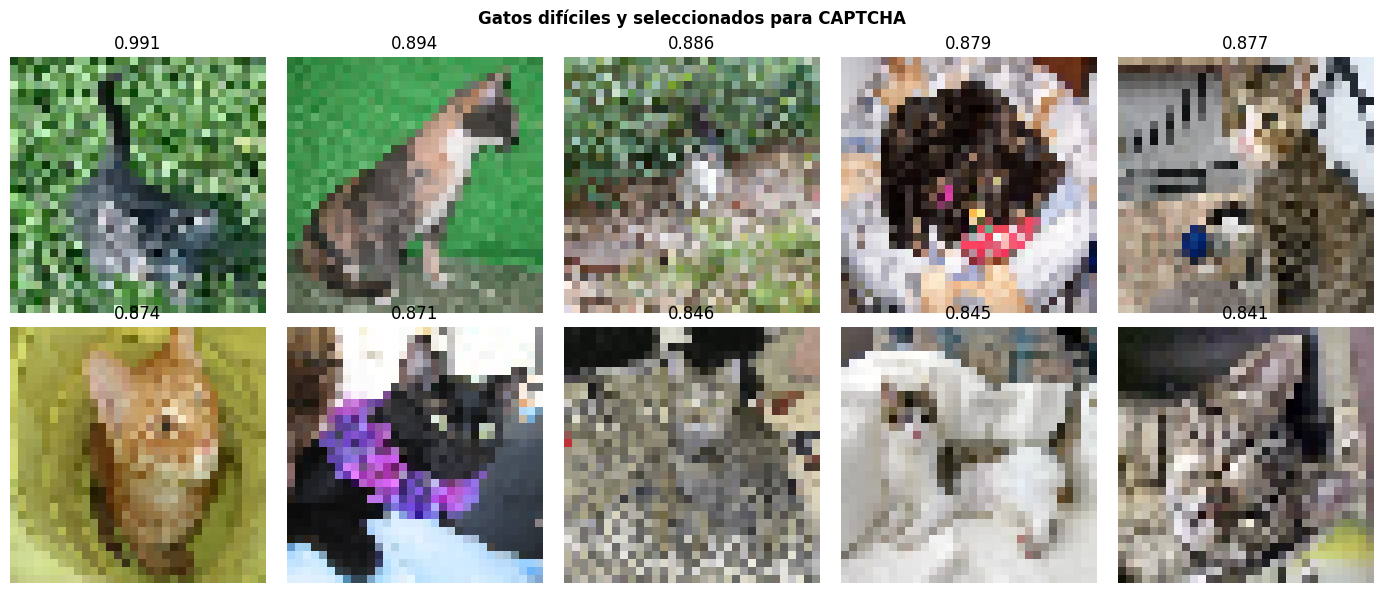

In [57]:
n = min(10, len(gatos_seleccionados))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Gatos difíciles y seleccionados para CAPTCHA",
             fontsize=12, fontweight='bold')

for i, idx in enumerate(gatos_seleccionados[:n]):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx])
    ax.set_title(f"{y_pred_proba[idx]:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

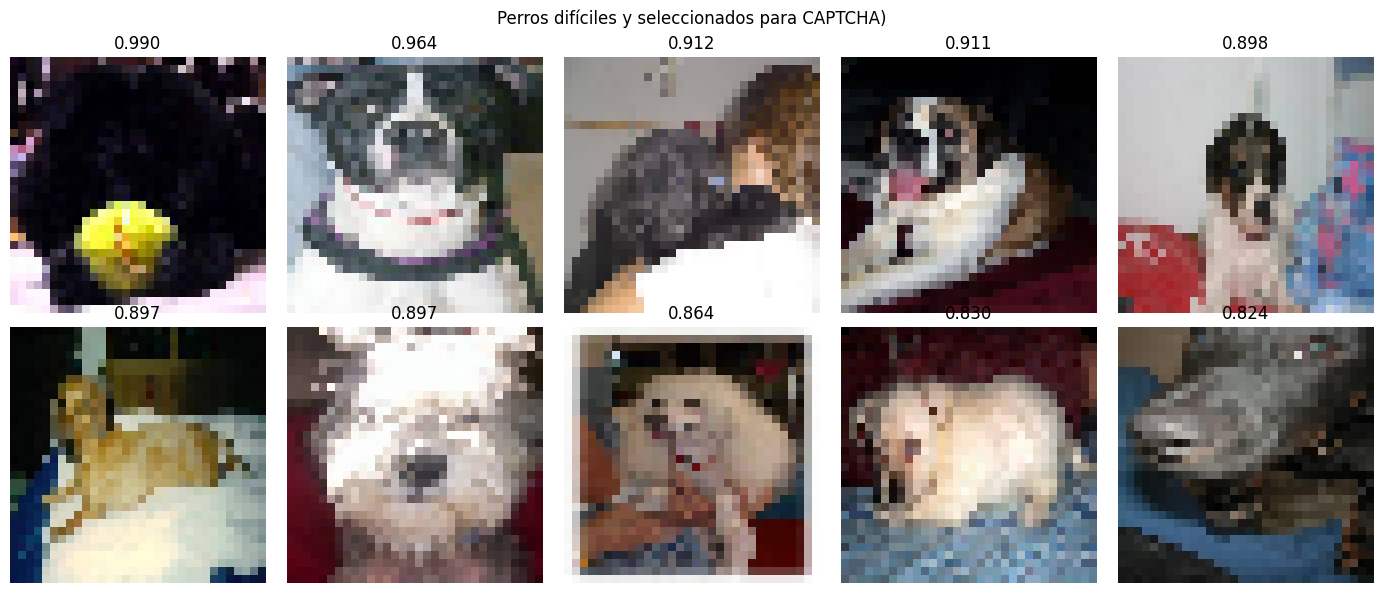

In [58]:
n = min(10, len(perros_seleccionados))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Perros difíciles y seleccionados para CAPTCHA)")

for i, idx in enumerate(perros_seleccionados[:n]):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx])
    ax.set_title(f"{1-y_pred_proba[idx]:.3f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# lista de imágenes difíciles para el CAPTCHA
df_gatos_dificiles = pd.DataFrame({
    'filename': test_filenames_arr[gatos_seleccionados],
    'clase_real': 'gato',
    'clase_predicha': 'perro',
    'confianza_clase_erronea': y_pred_proba[gatos_seleccionados]
})

df_perros_dificiles = pd.DataFrame({
    'filename': test_filenames_arr[perros_seleccionados],
    'clase_real': 'perro',
    'clase_predicha': 'gato',
    'confianza_clase_erronea': 1 - y_pred_proba[perros_seleccionados]
})

df_imagenes_captcha = pd.concat([df_gatos_dificiles, df_perros_dificiles], ignore_index=True)
df_imagenes_captcha = df_imagenes_captcha.sort_values('confianza_clase_erronea', ascending=False)

df_imagenes_captcha.to_csv('imagenes_dificiles_CAPTCHA.csv', index=False)

print("\nPrimeras 10 imágenes más difíciles")
df_imagenes_captcha.head(10)


Primeras 10 imágenes más difíciles


,filename,clase_real,clase_predicha,confianza_clase_erronea
0,cat.11793.jpg,gato,perro,0.991071
50,dog.8764.jpg,perro,gato,0.990306
51,dog.9346.jpg,perro,gato,0.964390
52,dog.9530.jpg,perro,gato,0.912129
53,dog.8215.jpg,perro,gato,0.910602
54,dog.8491.jpg,perro,gato,0.898301
55,dog.8951.jpg,perro,gato,0.897094
56,dog.8707.jpg,perro,gato,0.896774
1,cat.11462.jpg,gato,perro,0.893899
2,cat.10740.jpg,gato,perro,0.886464
